In [1]:
suppressPackageStartupMessages(library('mixOmics'))
suppressPackageStartupMessages(library('glmnet'))
suppressPackageStartupMessages(library('glue'))

suppressPackageStartupMessages(library('dplyr'))
suppressPackageStartupMessages(require(caret))
suppressPackageStartupMessages(library(data.table))    # provides enhanced data.frame
suppressPackageStartupMessages(library(ggplot2))      # plotting
suppressPackageStartupMessages(library(glmnet))        # ridge, elastic net, and lasso 
suppressPackageStartupMessages(library(gower))




In [2]:
data_dir <- '/media/josh/wd/data/IO_inhibitors/Kim2018_Gastric/Kim2018_PD1_Gastric_RNASeq'

In [22]:
hgnc <- rio::import('/media/josh/wd/data/ensembl_hgnc/hgnc_ncbi.txt')

In [45]:

X <- read.table(glue("{data_dir}/ICB.Kim2018_Pembrolizumab_Gastric.self_subtract"),header=TRUE,row.names=1,check.names=FALSE,sep="\t")
X <- t(X) %>% as.data.frame()
# X <- X[,colMeans(X)>=1]
X[1:5,1:3]
dim(X)

,1,29974,2
,<dbl>,<dbl>,<dbl>
PB-16-002,0.07075272,-1.4963102,-0.7731533
PB-16-003,-2.08976724,-0.2391706,0.5216315
PB-16-004,-1.43569557,0.9482747,0.9126401
PB-16-005,-0.76082723,-1.2400563,-0.3089506
PB-16-018,1.61998522,1.9214972,-2.7525771


[1]    45 25976

In [46]:
col_names <- colnames(X)
common_genes <- intersect(col_names, hgnc$`NCBI Gene ID`)
head(common_genes)

[1] "1"      "29974"  "2"      "144568" "3"      "127550"

In [51]:
hgnc_sub <- hgnc %>% filter(`NCBI Gene ID` %in% common_genes) %>% select(`Approved symbol`, `NCBI Gene ID`) %>% unique()
# hgnc_sub <- hgnc_sub[match(common_genes, hgnc$`NCBI Gene ID`), ]
ncbi_genes <- as.character(as.vector(hgnc_sub$`NCBI Gene ID`))
X <- X[, ncbi_genes]

In [54]:
if(all(colnames(X) == hgnc_sub$`NCBI Gene ID`)){
    
    colnames(X) <- hgnc_sub$`Approved symbol`
}

In [55]:
X[1:3, 1:3]

,A1BG,A1CF,A2M
,<dbl>,<dbl>,<dbl>
PB-16-002,0.07075272,-1.4963102,-0.7731533
PB-16-003,-2.08976724,-0.2391706,0.5216315
PB-16-004,-1.43569557,0.9482747,0.9126401


In [56]:
Y<-read.table(glue("{data_dir}/ICB.Kim2018_Pembrolizumab_Gastric.clinical"),header=TRUE,sep="\t", row.names = 1)
head(Y)
dim(Y)

,Response
,<dbl>
PB-16-045,1
PB-16-068,1
PB-16-031,1
PB-16-005,1
PB-16-010,1
PB-16-013,1


[1] 61  1

In [57]:
common_samples <- intersect(row.names(X), row.names(Y))

X <- X[common_samples, ]
Y <- Y[common_samples, drop = F, ]
all(row.names(X) == row.names(Y))

[1] TRUE

In [58]:
options(warn = -1)
corxy <- function(x){
  Y<- as.vector(Y$Response)
  res <- cor.test(Y,x)
  res$p.value  ##return pvalue
}


res_all <- apply(X, 2,corxy)

In [59]:
ordered_res_all <- sort(res_all, decreasing = FALSE)
ordered_res_all[1:5]

RAET1K      CXCR2P1       GRIN3A         LAP3         FZD3 
4.705299e-09 5.137340e-07 1.199111e-06 1.630446e-06 4.847160e-06

In [60]:
y = as.vector(Y$Response)
#x = model.matrix(y~.,ccle_expr[shared_cell_lines,expr_genes_matched])       # matrix of predictors
expr_genes_matched <- names(ordered_res_all[1:300])



x = X[,expr_genes_matched]
scaled.x=scale(x)

set.seed(123)                                # replicate  results
lasso_model <- cv.glmnet(scaled.x, y, alpha=1)         # alpha = 1 lasso
best_lambda_la <- lasso_model$lambda.1se     # largest lambda in 1 SE
lasso_coef <- lasso_model$glmnet.fit$beta[,        # retrieve coefficients
              lasso_model$glmnet.fit$lambda     # at lambda.1se
              == best_lambda_la]
coef_la = data.table::data.table(lassoReg = lasso_coef)   # build table
coef_la[, feature := names(lasso_coef)]      # add feature names
to_plot_r_la = melt(coef_la                     # label table
               , id.vars='feature'
               , variable.name = 'model'
               , value.name = 'coefficient')


In [61]:
head(to_plot_r_la)

feature,model,coefficient
<chr>,<fct>,<dbl>
RAET1K,lassoReg,0.04526727
CXCR2P1,lassoReg,0.00000000
GRIN3A,lassoReg,0.04219707
LAP3,lassoReg,0.08326835
FZD3,lassoReg,0.00000000
CXCL10,lassoReg,0.00000000


In [62]:
to_plot_r_la <-  to_plot_r_la %>% as.data.frame() %>% filter(coefficient != 0) %>% arrange(coefficient)
to_plot_r_la$feature <- factor(to_plot_r_la$feature, levels = unique(to_plot_r_la$feature))

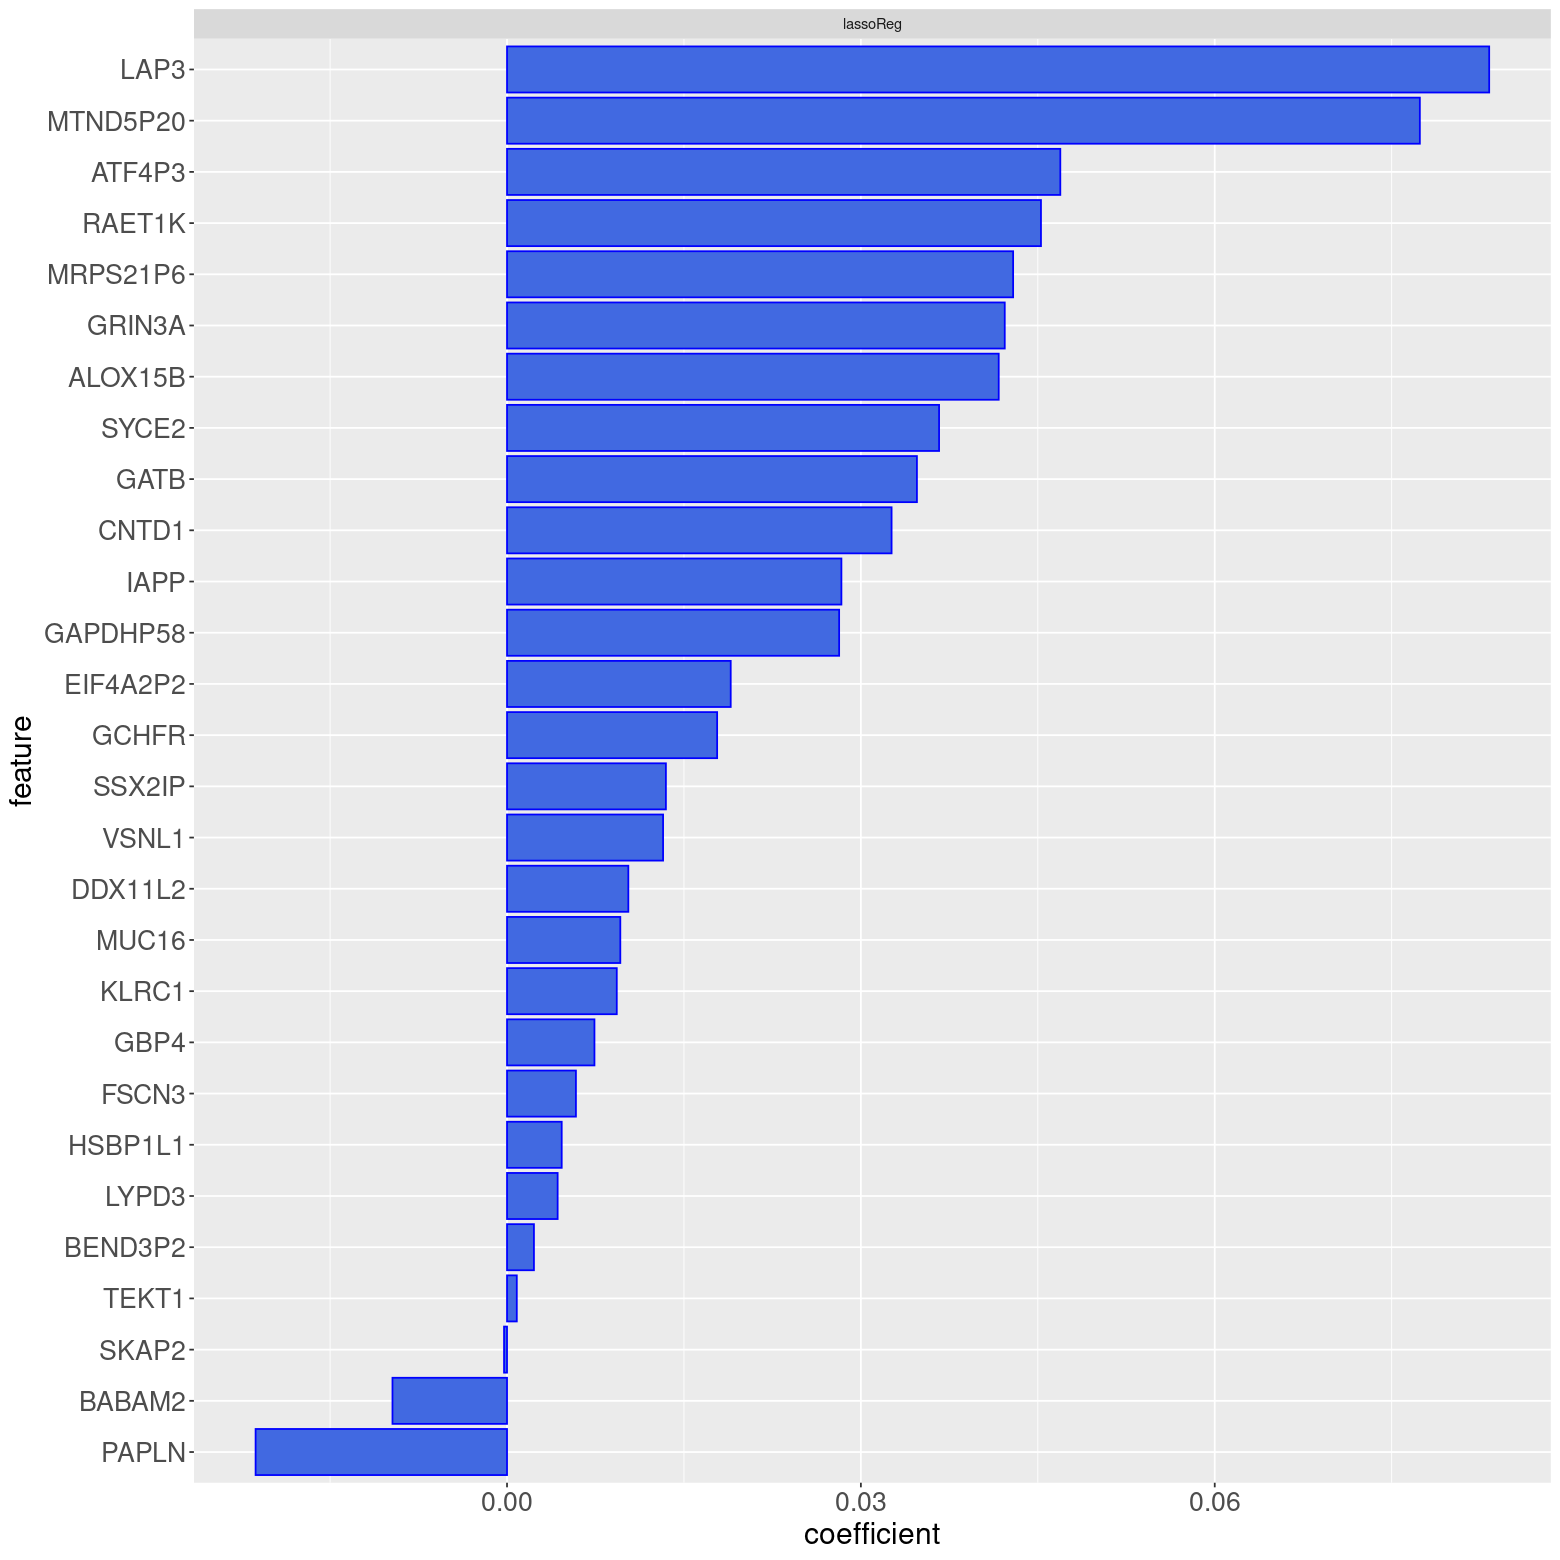

In [68]:
options(repr.plot.width = 13, repr.plot.height = 13)
ggplot(data=to_plot_r_la,                       # plot coefficients
       aes(x=feature, y=coefficient, fill=model)) +
       coord_flip() +         
       geom_bar(stat='identity', fill='royalblue', color='blue') +
       facet_wrap(~ model) + guides(fill=FALSE) +
theme(
  axis.title.x = element_text(size = 18),
  axis.text.x = element_text(size = 16),
  axis.title.y = element_text(size = 18), axis.text.y = element_text(size = 16))

In [64]:
to_plot_r_la

feature,model,coefficient
<fct>,<fct>,<dbl>
PAPLN,lassoReg,-0.0213162778
BABAM2,lassoReg,-0.0097115946
SKAP2,lassoReg,-0.0002524483
TEKT1,lassoReg,0.0008277271
BEND3P2,lassoReg,0.0022812531
LYPD3,lassoReg,0.0042910476
HSBP1L1,lassoReg,0.0046354841
FSCN3,lassoReg,0.0058404448
GBP4,lassoReg,0.0074115339
